In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import math

In [ ]:
# 1) Load data from uploaded CSV
df = pd.read_csv("laptops_model_data.csv")

In [ ]:
# Quick check of columns
print(df.columns)

Index(['Price', 'Brand_ID', 'OS_ID', 'spec_score', 'Gaming_Flag',
       'Release_Year', 'RAM_GB', 'SSD_GB', 'Screen_Inch'],
      dtype='object')


In [ ]:
# 2) Choose target and features
target_col = "price"
feature_cols = [
    "Brand_ID",
    "OS_ID",
    "spec_score",
    "Gaming_Flag",
    "Release_Year",
    "RAM_GB",
    "SSD_GB",
    "Screen_Inch",
]

In [ ]:
# If Gaming_Flag is text (e.g. 'Gaming'/'Non-Gaming'), convert to 0/1
if df["Gaming_Flag"].dtype == object:
    df["Gaming_Flag"] = (df["Gaming_Flag"].str.contains("Gaming", case=False)).astype(int)

X = df[feature_cols]
y = df[target_col]

# 3) Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


KeyError: 'price'

In [ ]:
df = pd.read_csv("laptops_model_data.csv")
print(df.columns)
df.head()

Index(['Price', 'Brand_ID', 'OS_ID', 'spec_score', 'Gaming_Flag',
       'Release_Year', 'RAM_GB', 'SSD_GB', 'Screen_Inch'],
      dtype='object')


,Price,Brand_ID,OS_ID,spec_score,Gaming_Flag,Release_Year,RAM_GB,SSD_GB,Screen_Inch
0,31990,1,1,74.0,Non-Gaming,2025,8,512,14.0
1,17990,2,1,NaN,Non-Gaming,2025,8,256,11.6
2,41500,1,1,74.0,Non-Gaming,2025,16,512,15.6
3,63990,2,1,81.0,Non-Gaming,2025,12,512,15.6
4,77990,1,2,81.0,Non-Gaming,2024,16,256,13.6


In [ ]:
target_col = "price"

In [ ]:
target_col = "Price"
# or
target_col = "price_inr"

In [ ]:
feature_cols = [
    "Brand_ID",      # or "brand_id"
    "OS_ID",         # or "os_id"
    "spec_score",    # check exact spelling
    "Gaming_Flag",   # or "gaming_flag"
    "Release_Year",  # or "release_year"
    "RAM_GB",
    "SSD_GB",
    "Screen_Inch",
]


In [ ]:
import pandas as pd

df = pd.read_csv("laptops_model_data.csv")
print(df.columns.tolist())
print(df.head(3))


['Price', 'Brand_ID', 'OS_ID', 'spec_score', 'Gaming_Flag', 'Release_Year', 'RAM_GB', 'SSD_GB', 'Screen_Inch']
   Price  Brand_ID  OS_ID  spec_score Gaming_Flag  Release_Year  RAM_GB  \
0  31990         1      1        74.0  Non-Gaming          2025       8   
1  17990         2      1         NaN  Non-Gaming          2025       8   
2  41500         1      1        74.0  Non-Gaming          2025      16   

   SSD_GB  Screen_Inch  
0     512         14.0  
1     256         11.6  
2     512         15.6  


In [ ]:
df = pd.read_csv("laptops_model_data.csv")

# Add a serial number column starting at 1
df.insert(0, "S_No", range(1, len(df) + 1))

print(df.head(3))


   S_No  Price  Brand_ID  OS_ID  spec_score Gaming_Flag  Release_Year  RAM_GB  \
0     1  31990         1      1        74.0  Non-Gaming          2025       8   
1     2  17990         2      1         NaN  Non-Gaming          2025       8   
2     3  41500         1      1        74.0  Non-Gaming          2025      16   

   SSD_GB  Screen_Inch  
0     512         14.0  
1     256         11.6  
2     512         15.6  


In [ ]:
df.to_csv("laptops_model_data_with_sno.csv", index=False)

In [ ]:
target_col = "Price"
feature_cols = ["Brand_ID","OS_ID","spec_score","Gaming_Flag",
                "Release_Year","RAM_GB","SSD_GB","Screen_Inch"]

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import math

In [ ]:
# 1) Load data
df = pd.read_csv("laptops_model_data.csv")

In [ ]:
# Optional: add S_No starting at 1 (only for readability)
df.insert(0, "S_No", range(1, len(df) + 1))

In [ ]:
# 2) Target and features
target_col = "Price"
feature_cols = [
    "Brand_ID",
    "OS_ID",
    "spec_score",
    "Gaming_Flag",
    "Release_Year",
    "RAM_GB",
    "SSD_GB",
    "Screen_Inch",
]

In [ ]:
# Convert Gaming_Flag text to 0/1
if df["Gaming_Flag"].dtype == object:
    df["Gaming_Flag"] = (df["Gaming_Flag"].str.contains("Gaming", case=False)).astype(int)
    X = df[feature_cols]
y = df[target_col]

# 3) Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# 4) Train model
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)

In [ ]:
# 5) Evaluate
y_pred = model.predict(X_test)
rmse = math.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Test RMSE:", rmse)
print("Test R^2:", r2)


Test RMSE: 27661.00821591
Test R^2: 0.6820797089798698


In [ ]:
# 6) One example prediction
sample = X_test.iloc[[0]]
print("Sample features:\n", sample)
print("Actual price:", float(y_test.iloc[0]))
print("Predicted price:", float(model.predict(sample)[0]))

Sample features:
      Brand_ID  OS_ID  spec_score  Gaming_Flag  Release_Year  RAM_GB  SSD_GB  \
937         4      1        77.0            1          2023      16     512   

     Screen_Inch  
937         15.6  
Actual price: 55990.0
Predicted price: 60718.751249999994


In [ ]:
# Handle missing spec_score: fill NaN with column mean
spec_mean = df["spec_score"].mean()
df["spec_score"] = df["spec_score"].fillna(spec_mean)
print("Filled spec_score NaN with mean:", spec_mean)


Filled spec_score NaN with mean: 78.79612468407751


In [ ]:
# Simple CPU strength proxy (0 = low, 1 = mid, 2 = high)
def cpu_strength(row):
    # Very rough rule of thumb
    if row["RAM_GB"] >= 16:
        return 2
    elif row["RAM_GB"] >= 8:
        return 1
    else:
        return 0
        df["CPU_strength"] = df.apply(cpu_strength, axis=1)

In [ ]:
feature_cols = [
    "Brand_ID",
    "OS_ID",
    "spec_score",
    "Gaming_Flag",
    "Release_Year",
    "RAM_GB",
    "SSD_GB",
    "Screen_Inch",
    "CPU_strength",
]


In [ ]:
print("Test RMSE:", rmse)
print("Test R^2:", r2)


Test RMSE: 27661.00821591
Test R^2: 0.6820797089798698


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import math

# 1) Load data
df = pd.read_csv("laptops_model_data.csv")

# Optional: add S_No starting at 1 (only for readability)
df.insert(0, "S_No", range(1, len(df) + 1))

# 2) Handle missing spec_score
spec_mean = df["spec_score"].mean()
df["spec_score"] = df["spec_score"].fillna(spec_mean)
print("Filled spec_score NaN with mean:", spec_mean)

# 3) Convert Gaming_Flag text to 0/1
if df["Gaming_Flag"].dtype == object:
    df["Gaming_Flag"] = (df["Gaming_Flag"].str.contains("Gaming", case=False)).astype(int)

# 4) Add CPU_strength feature
def cpu_strength(row):
    if row["RAM_GB"] >= 16:
        return 2
    elif row["RAM_GB"] >= 8:
        return 1
    else:
        return 0

df["CPU_strength"] = df.apply(cpu_strength, axis=1)

# 5) Target and features
target_col = "Price"
feature_cols = [
    "Brand_ID",
    "OS_ID",
    "spec_score",
    "Gaming_Flag",
    "Release_Year",
    "RAM_GB",
    "SSD_GB",
    "Screen_Inch",
    "CPU_strength",
]

X = df[feature_cols]
y = df[target_col]

# 6) Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


Filled spec_score NaN with mean: 78.79612468407751


In [ ]:
# 7) Train model
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

# 8) Evaluate
y_pred = model.predict(X_test)
rmse = math.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Test RMSE:", rmse)
print("Test R^2:", r2)

# 9) Example prediction
sample = X_test.iloc[[0]]
print("Sample features:\n", sample)
print("Actual price:", float(y_test.iloc[0]))
print("Predicted price:", float(model.predict(sample)[0]))

Test RMSE: 28006.004000416826
Test R^2: 0.6740998735153796
Sample features:
      Brand_ID  OS_ID  spec_score  Gaming_Flag  Release_Year  RAM_GB  SSD_GB  \
937         4      1        77.0            1          2023      16     512   

     Screen_Inch  CPU_strength  
937         15.6             2  
Actual price: 55990.0
Predicted price: 62817.53166666667


In [ ]:
print("Test RMSE:", rmse)
print("Test R^2:", r2)


Test RMSE: 28006.004000416826
Test R^2: 0.6740998735153796


In [ ]:
# Retrain on full dataset (all rows)
X_full = df[feature_cols]
y_full = df[target_col]

final_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
final_model.fit(X_full, y_full)

# Predictions for all laptops
df["Predicted_Price"] = final_model.predict(X_full)


In [ ]:
output_cols = [
    "Price",
    "Brand_ID",
    "OS_ID",
    "spec_score",
    "Gaming_Flag",
    "Release_Year",
    "RAM_GB",
    "SSD_GB",
    "Screen_Inch",
    "Predicted_Price",
]

df[output_cols].to_csv("laptop_predictions.csv", index=False)
print("Saved laptop_predictions.csv")


Saved laptop_predictions.csv


In [ ]:
# 1) Retrain on full dataset
X_full = df[feature_cols]
y_full = df[target_col]

from sklearn.ensemble import RandomForestRegressor

final_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
final_model.fit(X_full, y_full)

# 2) Add Predicted_Price column
df["Predicted_Price"] = final_model.predict(X_full)

# 3) Save a new CSV
df.to_csv("laptop_predictions.csv", index=False)
print("Saved laptop_predictions.csv")


Saved laptop_predictions.csv


In [ ]:
df.to_csv("laptop_predictions.csv", index=False)


In [ ]:
# 1) Make sure df is loaded and has features + trained model

# If needed, reload:
df = pd.read_csv("laptops_model_data.csv")

# Recreate all preprocessing
df["spec_score"] = df["spec_score"].fillna(df["spec_score"].mean())
if df["Gaming_Flag"].dtype == object:
    df["Gaming_Flag"] = (df["Gaming_Flag"].str.contains("Gaming", case=False)).astype(int)

feature_cols = [
    "Brand_ID",
    "OS_ID",
    "spec_score",
    "Gaming_Flag",
    "Release_Year",
    "RAM_GB",
    "SSD_GB",
    "Screen_Inch",
]

X_full = df[feature_cols]
y_full = df["Price"]

from sklearn.ensemble import RandomForestRegressor

final_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
final_model.fit(X_full, y_full)

# 2) Add predictions and RESAVE
df["Predicted_Price"] = final_model.predict(X_full)

df.to_csv("laptop_predictions.csv", index=False)
print("Saved laptop_predictions.csv with Predicted_Price")


Saved laptop_predictions.csv with Predicted_Price


In [ ]:
df.head()


,Price,Brand_ID,OS_ID,spec_score,Gaming_Flag,Release_Year,RAM_GB,SSD_GB,Screen_Inch,Predicted_Price
0,31990,1,1,74.000000,1,2025,8,512,14.0,33653.010405
1,17990,2,1,78.796125,1,2025,8,256,11.6,22532.895000
2,41500,1,1,74.000000,1,2025,16,512,15.6,48576.935000
3,63990,2,1,81.000000,1,2025,12,512,15.6,62332.307333
4,77990,1,2,81.000000,1,2024,16,256,13.6,83784.700000


In [ ]:
# Error per row (signed and absolute)
df["Error"] = df["Predicted_Price"] - df["Price"]
df["Abs_Error"] = df["Error"].abs()
df["Pct_Error"] = df["Abs_Error"] / df["Price"] * 100

# Quick check of first rows
df[["Price", "Predicted_Price", "Error", "Abs_Error", "Pct_Error"]].head()


,Price,Predicted_Price,Error,Abs_Error,Pct_Error
0,31990,33653.010405,1663.010405,1663.010405,5.198532
1,17990,22532.895000,4542.895000,4542.895000,25.252335
2,41500,48576.935000,7076.935000,7076.935000,17.052855
3,63990,62332.307333,-1657.692667,1657.692667,2.590550
4,77990,83784.700000,5794.700000,5794.700000,7.430055


In [ ]:
print("Average absolute error:", df["Abs_Error"].mean())
print("Median absolute error:", df["Abs_Error"].median())
print("Max absolute error:", df["Abs_Error"].max())

print("Average % error:", df["Pct_Error"].mean())
print("Median % error:", df["Pct_Error"].median())
print("Max % error:", df["Pct_Error"].max())


Average absolute error: 8066.726779669112
Median absolute error: 4945.082499999997
Max absolute error: 81016.01361471863
Average % error: 11.049338901734282
Median % error: 7.7414489215581135
Max % error: 169.92785676671934


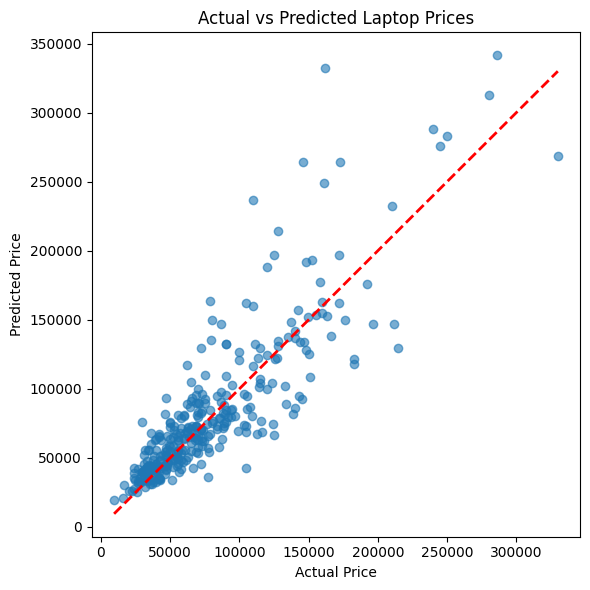

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Laptop Prices")
plt.tight_layout()
plt.savefig("actual_vs_predicted.png", dpi=300)
plt.show()


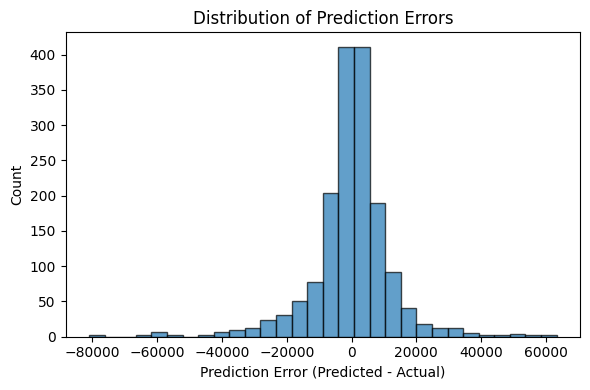

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(df["Error"], bins=30, edgecolor="black", alpha=0.7)
plt.xlabel("Prediction Error (Predicted - Actual)")
plt.ylabel("Count")
plt.title("Distribution of Prediction Errors")
plt.tight_layout()
plt.savefig("error_distribution.png", dpi=300)
plt.show()


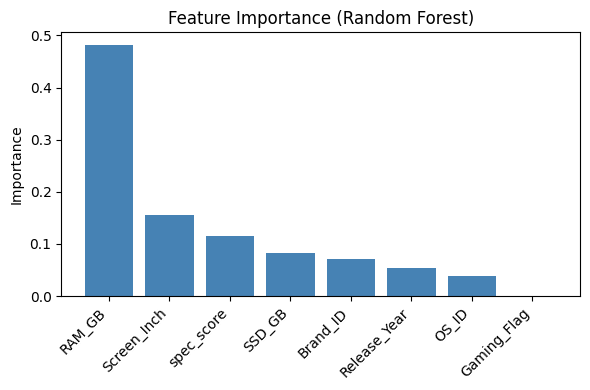

In [ ]:
import numpy as np

importances = final_model.feature_importances_
indices = np.argsort(importances)[::-1]
names = np.array(feature_cols)[indices]

plt.figure(figsize=(6,4))
plt.bar(range(len(feature_cols)), importances[indices], color="steelblue")
plt.xticks(range(len(feature_cols)), names, rotation=45, ha="right")
plt.ylabel("Importance")
plt.title("Feature Importance (Random Forest)")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=300)
plt.show()


In [ ]:
num_cols = [
    "Price",
    "Predicted_Price",
    "Brand_ID",
    "OS_ID",
    "spec_score",
    "Gaming_Flag",
    "Release_Year",
    "RAM_GB",
    "SSD_GB",
    "Screen_Inch",
]

corr = df[num_cols].corr()


In [ ]:
num_cols = [
    "Price",
    "Predicted_Price",
    "Brand_ID",
    "OS_ID",
    "spec_score",
    "Gaming_Flag",
    "Release_Year",
    "RAM_GB",
    "SSD_GB",
    "Screen_Inch",
    "CPU_strength",
]

# Keep only the columns that are present in df
num_cols = [c for c in num_cols if c in df.columns]

corr = df[num_cols].corr()


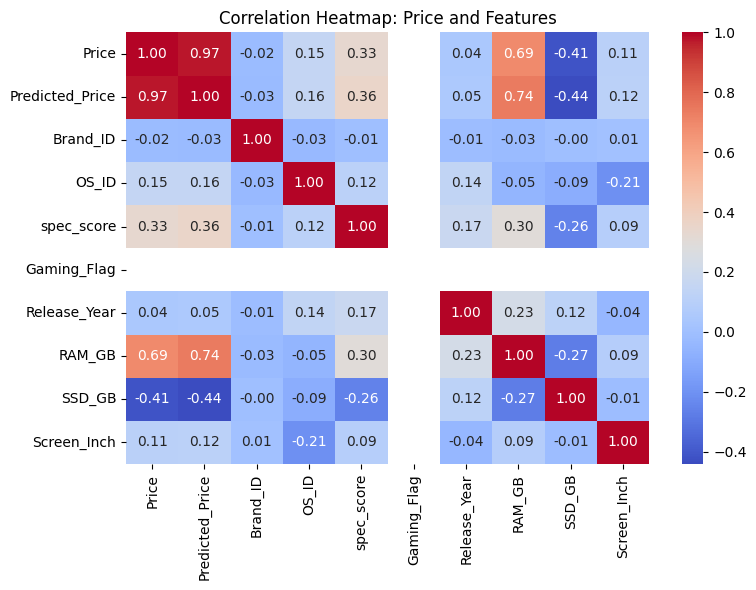

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Only columns that exist
num_cols = [
    "Price",
    "Predicted_Price",
    "Brand_ID",
    "OS_ID",
    "spec_score",
    "Gaming_Flag",
    "Release_Year",
    "RAM_GB",
    "SSD_GB",
    "Screen_Inch",
]

corr = df[num_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap: Price and Features")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=300)
plt.show()


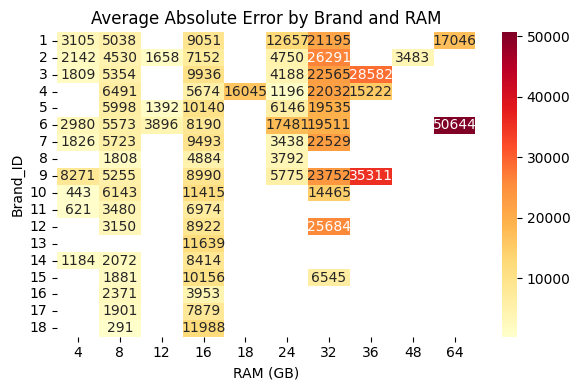

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Make sure Error exists (from earlier step)
# df["Error"] = df["Predicted_Price"] - df["Price"]

pivot = df.pivot_table(
    values="Abs_Error",          # or "Pct_Error"
    index="Brand_ID",
    columns="RAM_GB",
    aggfunc="mean"
)

plt.figure(figsize=(6,4))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlOrRd")
plt.title("Average Absolute Error by Brand and RAM")
plt.xlabel("RAM (GB)")
plt.ylabel("Brand_ID")
plt.tight_layout()
plt.savefig("error_heatmap_brand_ram.png", dpi=300)
plt.show()


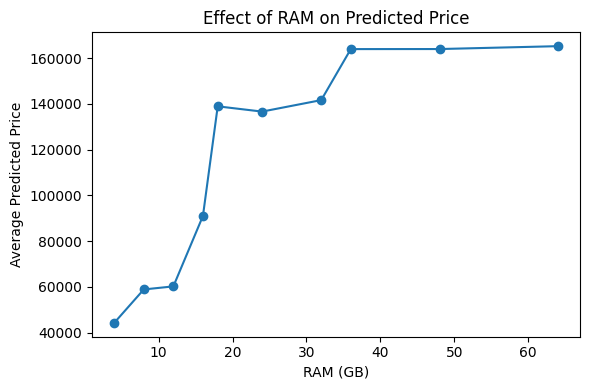

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Choose feature to analyze
feature = "RAM_GB"

# Unique sorted values of RAM
vals = np.sort(df[feature].unique())

avg_preds = []
for v in vals:
    tmp = df.copy()
    tmp[feature] = v
    avg_preds.append(final_model.predict(tmp[feature_cols]).mean())

plt.figure(figsize=(6,4))
plt.plot(vals, avg_preds, marker="o")
plt.xlabel("RAM (GB)")
plt.ylabel("Average Predicted Price")
plt.title("Effect of RAM on Predicted Price")
plt.tight_layout()
plt.savefig("pdp_ram.png", dpi=300)
plt.show()


In [ ]:
summary = f"""
Random forest regression model for laptop prices:
- Test RMSE: {rmse:,.0f}
- Test R²: {r2:.2f}
- Average absolute error: {df['Abs_Error'].mean():,.0f}
- Median absolute error: {df['Abs_Error'].median():,.0f}
- Average % error: {df['Pct_Error'].mean():.1f}%
"""

print(summary)



Random forest regression model for laptop prices:
- Test RMSE: 28,006
- Test R²: 0.67
- Average absolute error: 8,067
- Median absolute error: 4,945
- Average % error: 11.0%



In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load your original dataset
df = pd.read_csv("laptops_model_data.csv")

# 2. Keep only numeric columns you care about
num_cols = ["price", "RAMGB", "SSDGB", "ScreenInch", "rating100", "specscore"]
data_num = df[num_cols]

# 3. Correlation matrix (dataset only, no predicted values)
corr = data_num.corr()

# 4. Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation heatmap of original dataset (before prediction)")
plt.tight_layout()
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'laptops_model_data.csv'

In [ ]:
import os
print(os.getcwd())


/content


In [ ]:
df = pd.read_csv(r"/laptops_model_data.csv")


In [ ]:
import os
print(os.listdir())


['.config', 'sample_data']


In [ ]:
from google.colab import files
uploaded = files.upload()   # choose laptops_model_data.csv from your computer
print(uploaded.keys())      # should show 'laptops_model_data.csv'
import pandas as pd
df = pd.read_csv("laptops_model_data.csv")
df.head()


Saving laptops_model_data.csv to laptops_model_data.csv
dict_keys(['laptops_model_data.csv'])


,Price,Brand_ID,OS_ID,spec_score,Gaming_Flag,Release_Year,RAM_GB,SSD_GB,Screen_Inch
0,31990,1,1,74.0,Non-Gaming,2025,8,512,14.0
1,17990,2,1,NaN,Non-Gaming,2025,8,256,11.6
2,41500,1,1,74.0,Non-Gaming,2025,16,512,15.6
3,63990,2,1,81.0,Non-Gaming,2025,12,512,15.6
4,77990,1,2,81.0,Non-Gaming,2024,16,256,13.6


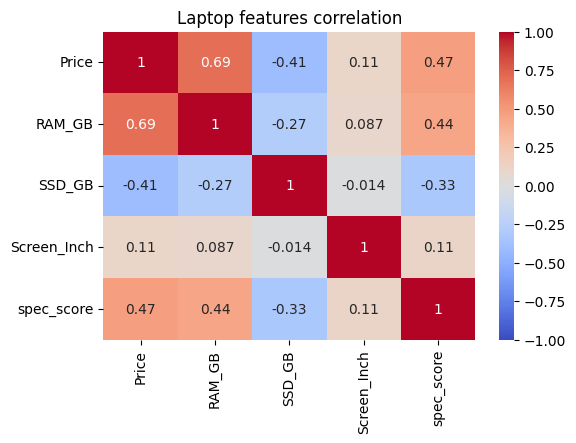

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1) Select numeric columns you care about
num_cols = ["Price","RAM_GB","SSD_GB","Screen_Inch","spec_score"]  # adapt to your exact column names

# 2) Compute correlation matrix
corr = df[num_cols].corr()

# 3) Plot heatmap
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Laptop features correlation")
plt.show()


In [ ]:
from google.colab import files
uploaded = files.upload()   # choose laptops_model_data.csv from your computer
print(uploaded.keys())      # should show 'laptops_model_data.csv'
import pandas as pd
df = pd.read_csv("laptops_model_data.csv")
df.head()


Saving laptops_model_data.csv to laptops_model_data.csv
dict_keys(['laptops_model_data.csv'])


,Price,Brand_ID,OS_ID,spec_score,Gaming_Flag,Release_Year,RAM_GB,SSD_GB,Screen_Inch
0,31990,1,1,74.0,Non-Gaming,2025,8,512,14.0
1,17990,2,1,NaN,Non-Gaming,2025,8,256,11.6
2,41500,1,1,74.0,Non-Gaming,2025,16,512,15.6
3,63990,2,1,81.0,Non-Gaming,2025,12,512,15.6
4,77990,1,2,81.0,Non-Gaming,2024,16,256,13.6


In [ ]:
import pandas as pd

df = pd.read_csv("laptops_model_data.csv")   # or read_excel("Laptops_Project.xlsx")


In [ ]:
print(df.columns.tolist())


['Price', 'Brand_ID', 'OS_ID', 'spec_score', 'Gaming_Flag', 'Release_Year', 'RAM_GB', 'SSD_GB', 'Screen_Inch']


In [ ]:
total_laptops = len(df)              # KPI 1
avg_price = df["Price"].mean()       # KPI 2
avg_spec  = df["spec_score"].mean()  # KPI 3


In [ ]:
print(total_laptops, avg_price, avg_spec)


1635 79901.22691131498 78.79612468407751


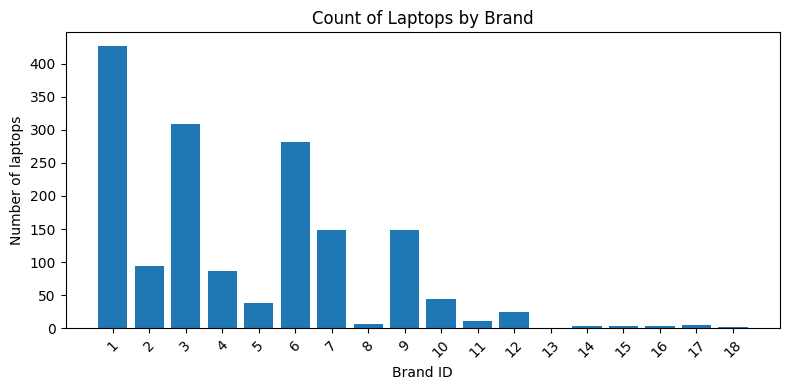

In [ ]:
import matplotlib.pyplot as plt

counts = df["Brand_ID"].value_counts().sort_index()

plt.figure(figsize=(8,4))
plt.bar(counts.index.astype(str), counts.values)
plt.xlabel("Brand ID")
plt.ylabel("Number of laptops")
plt.title("Count of Laptops by Brand")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


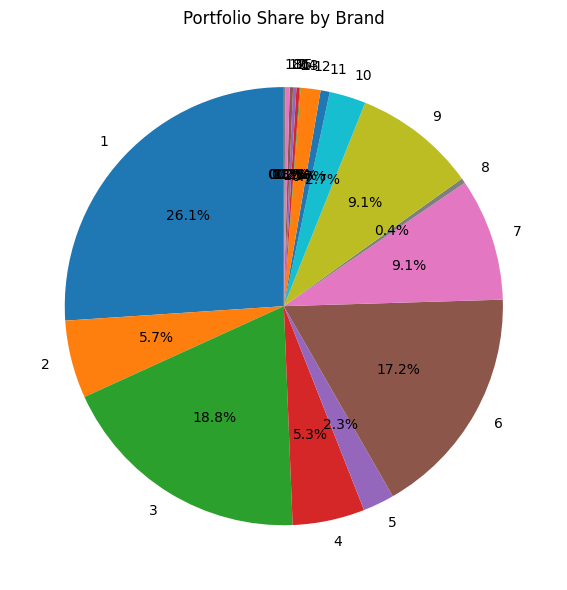

In [ ]:
import matplotlib.pyplot as plt

brand_counts = df["Brand_ID"].value_counts().sort_index()

plt.figure(figsize=(6,6))
plt.pie(
    brand_counts.values,
    labels=brand_counts.index.astype(str),   # later replace with real names
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Portfolio Share by Brand")
plt.tight_layout()
plt.show()


In [ ]:
len(df)                      # total laptops
df["Gaming_Flag"].value_counts()
df.describe()                # numeric summary
df["Release_Year"].value_counts().sort_index()


,count
Release_Year,
2018,3
2019,12
2020,18
2021,33
2022,409
2023,598
2024,409
2025,153


In [ ]:
n_total = len(df)
gaming_counts = df["Gaming_Flag"].value_counts()
gaming_pct = (gaming_counts.get("Gaming", 0) / n_total) * 100
nongaming_pct = (gaming_counts.get("Non-Gaming", 0) / n_total) * 100
gaming_counts, gaming_pct, nongaming_pct


(Gaming_Flag
 Non-Gaming    1347
 Gaming         288
 Name: count, dtype: int64,
 np.float64(17.61467889908257),
 np.float64(82.38532110091742))

In [ ]:
df["Price"].describe()
df[["RAM_GB","SSD_GB"]].describe()
df.groupby("Gaming_Flag")["spec_score"].mean()
df["Screen_Inch"].value_counts().head()


,count
Screen_Inch,
15.6,822
14.0,420
16.0,145
17.3,33
13.6,31


In [ ]:
df["Price"].min(), df["Price"].max()
df["RAM_GB"].max(), df["SSD_GB"].max()
df["spec_score"].max()
df["Screen_Inch"].max()


18.0

In [ ]:
# 1) Find the maximum price
max_price = df["Price"].max()

# 2) Filter the row(s) with that price
most_expensive = df[df["Price"] == max_price]

# 3) View key columns
most_expensive[["Price", "Brand_ID", "Gaming_Flag", "RAM_GB", "SSD_GB", "Screen_Inch", "spec_score"]]


,Price,Brand_ID,Gaming_Flag,RAM_GB,SSD_GB,Screen_Inch,spec_score
1518,396990,3,Gaming,32,0,16.0,NaN
